In [1]:
# CELL 1: Imports and Load Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for better visuals
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print("📊 Loading data for EDA and Feature Engineering...\n")

# Load the data from previous notebook
df = pd.read_csv("C:/Users/arjol/OneDrive/Desktop/final_dataset.csv")

print(f"✅ Dataset loaded: {df.shape[0]} stocks × {df.shape[1]} columns")
print(f"Number of high-growth stocks (3x+ in 5 years): {df['high_growth'].sum()} ({df['high_growth'].mean():.2%})")

display(df.head())

📊 Loading data for EDA and Feature Engineering...

✅ Dataset loaded: 175 stocks × 16 columns
Number of high-growth stocks (3x+ in 5 years): 21 (12.00%)


,ticker,company_name,sector,industry,market_cap,current_price,forward_pe,trailing_pe,peg_ratio,revenue_growth,earnings_growth,return_on_equity,debt_to_equity,beta,return_5y,high_growth
0,MRNA,"Moderna, Inc.",Healthcare,Biotechnology,2.018230e+10,50.890,-10.961696,NaN,NaN,-0.298,NaN,-0.28868,15.087,1.336,-0.638873,False
1,TMUS,"T-Mobile US, Inc.",Communication Services,Telecom Services,2.197698e+11,196.485,14.109675,20.214506,NaN,0.113,-0.266,0.18177,208.851,0.422,0.582217,False
2,FANG,"Diamondback Energy, Inc.",Energy,Oil & Gas E&P,5.263453e+10,186.595,12.051123,32.507843,NaN,-0.094,NaN,0.03735,33.784,0.488,2.087514,True
3,ELV,"Elevance Health, Inc.",Healthcare,Healthcare Plans,7.040479e+10,319.000,10.836404,12.648692,NaN,0.095,0.363,0.13250,74.388,0.498,-0.051830,False
4,MAS,Masco Corporation,Industrials,Building Products & Equipment,1.293312e+10,63.520,13.747847,16.455960,NaN,-0.019,-0.059,71.50000,4230.263,1.291,0.105682,False


In [2]:
# CELL 2: Summary of High-Growth Stocks

print("🔥 Top 21 High-Growth Stocks (3x+ return)\n")

high_growth_stocks = df[df['high_growth'] == True].sort_values('return_5y', ascending=False)

display(high_growth_stocks[['ticker', 'company_name', 'sector', 'return_5y']].round(2).head(21))

# Summary statistics
print("\n5-Year Return Statistics:")
print(df['return_5y'].describe().round(3))

🔥 Top 21 High-Growth Stocks (3x+ return)



,ticker,company_name,sector,return_5y
17,NVDA,NVIDIA Corporation,Technology,12.04
109,LITE,Lumentum Holdings Inc.,Technology,8.93
124,ASTS,"AST SpaceMobile, Inc.",Technology,8.61
94,PWR,"Quanta Services, Inc.",Industrials,5.29
151,SMCI,"Super Micro Computer, Inc.",Technology,5.14
31,SATS,EchoStar Corporation,Communication Services,3.97
140,NRG,"NRG Energy, Inc.",Utilities,3.90
142,MPC,Marathon Petroleum Corporation,Energy,3.70
86,MCK,McKesson Corporation,Healthcare,3.65
48,STLD,"Steel Dynamics, Inc.",Basic Materials,3.07



5-Year Return Statistics:
count    175.000
mean       0.911
std        1.601
min       -0.763
25%        0.011
50%        0.576
75%        1.323
max       12.040
Name: return_5y, dtype: float64


Creating plots and saving them...

✅ SUCCESS! All plots have been saved in the 'visualizations' folder.
Saved files:
   • visualizations/eda_5year_returns_distribution.png
   • visualizations/eda_high_growth_by_sector.png
   • visualizations/eda_revenue_vs_return.png
   • visualizations/combined_eda_dashboard.png


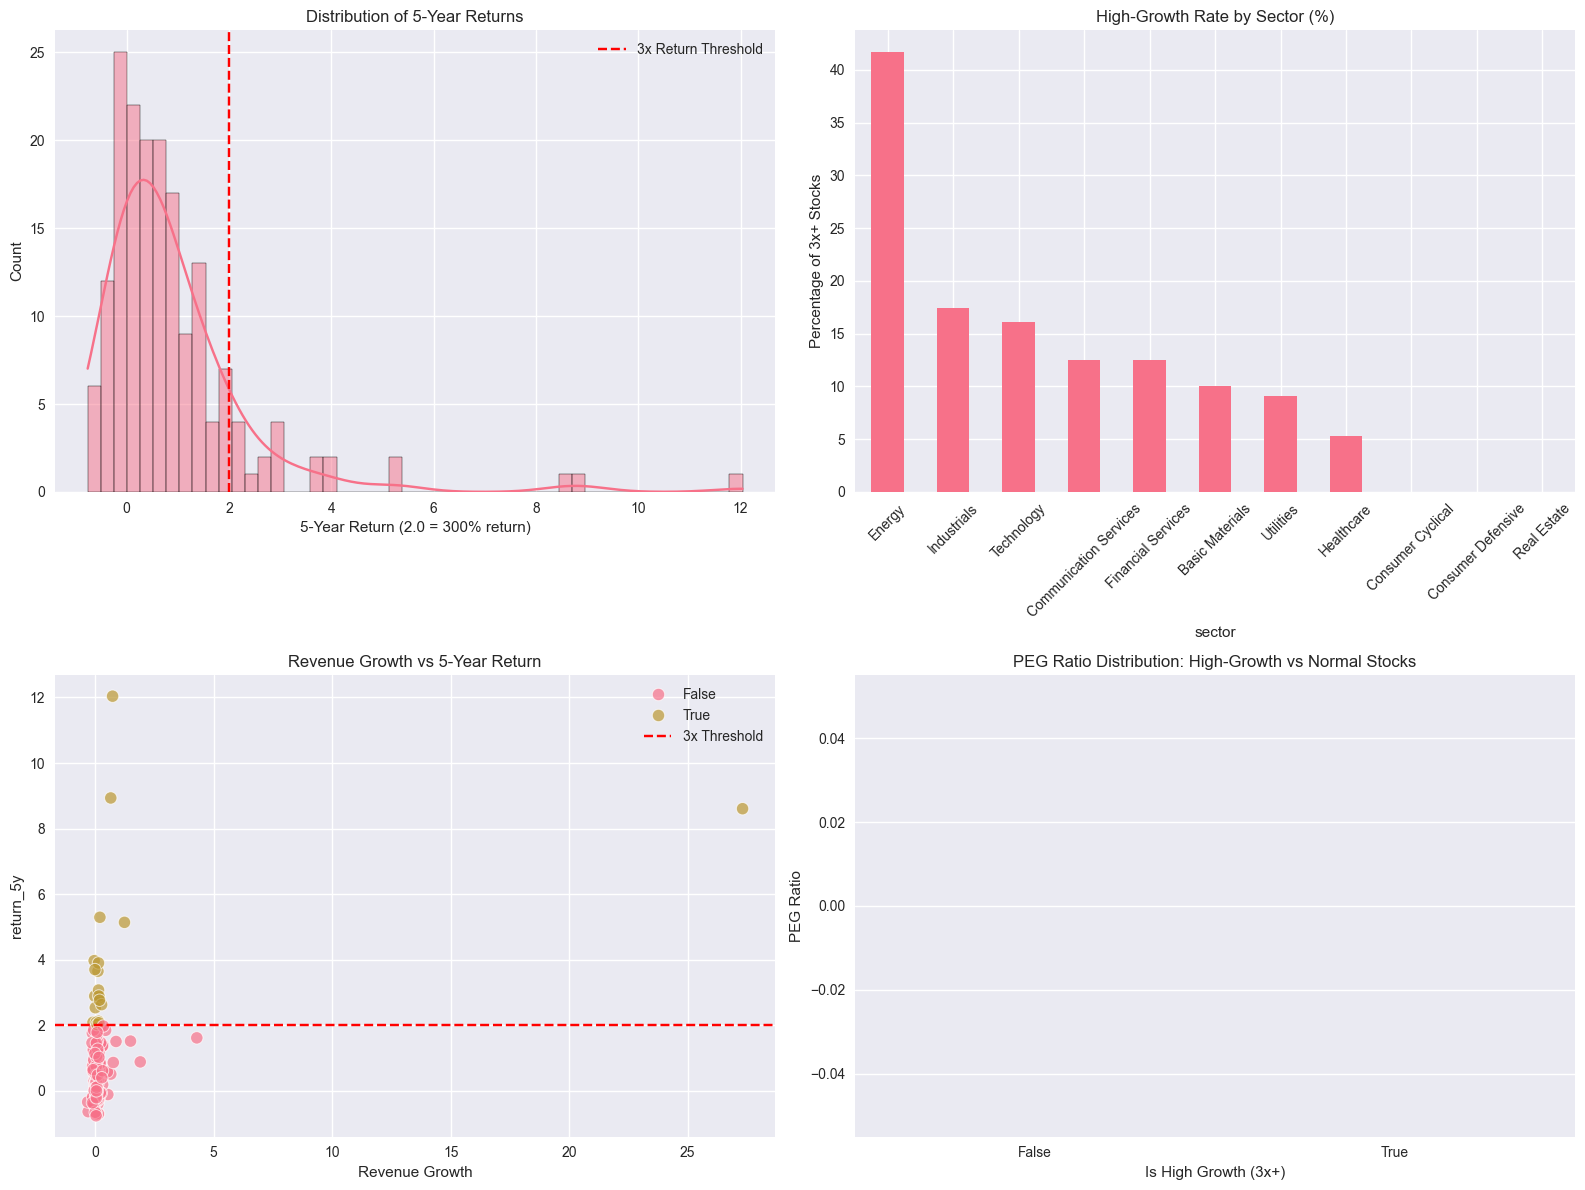

In [3]:
# CELL 3: Visual EDA + Save High-Quality Images for PPT (Safe Version)

import os
os.makedirs("visualizations", exist_ok=True)

print("Creating plots and saving them...\n")

# Create the figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribution of 5-Year Returns
sns.histplot(df['return_5y'], bins=50, kde=True, ax=axes[0,0])
axes[0,0].axvline(x=2.0, color='red', linestyle='--', label='3x Return Threshold')
axes[0,0].set_title('Distribution of 5-Year Returns')
axes[0,0].set_xlabel('5-Year Return (2.0 = 300% return)')
axes[0,0].legend()

# 2. High-Growth Rate by Sector
sector_perf = df.groupby('sector')['high_growth'].mean().sort_values(ascending=False) * 100
sector_perf.plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('High-Growth Rate by Sector (%)')
axes[0,1].set_ylabel('Percentage of 3x+ Stocks')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Revenue Growth vs 5-Year Return
sns.scatterplot(data=df, x='revenue_growth', y='return_5y', hue='high_growth', 
                ax=axes[1,0], s=80, alpha=0.7)
axes[1,0].set_title('Revenue Growth vs 5-Year Return')
axes[1,0].set_xlabel('Revenue Growth')
axes[1,0].axhline(y=2.0, color='red', linestyle='--', label='3x Threshold')
axes[1,0].legend()

# 4. PEG Ratio: High-Growth vs Normal (Simplified - No boxplot error)
sns.violinplot(data=df, x='high_growth', y='peg_ratio', ax=axes[1,1], 
               palette="Set2", inner="quartile")
axes[1,1].set_title('PEG Ratio Distribution: High-Growth vs Normal Stocks')
axes[1,1].set_xlabel('Is High Growth (3x+)')
axes[1,1].set_ylabel('PEG Ratio')

plt.tight_layout()

# ====================== SAVE THE PLOTS ======================
plt.savefig("visualizations/eda_5year_returns_distribution.png", dpi=300, bbox_inches='tight')
plt.savefig("visualizations/eda_high_growth_by_sector.png", dpi=300, bbox_inches='tight')
plt.savefig("visualizations/eda_revenue_vs_return.png", dpi=300, bbox_inches='tight')
plt.savefig("visualizations/combined_eda_dashboard.png", dpi=300, bbox_inches='tight')

print("✅ SUCCESS! All plots have been saved in the 'visualizations' folder.")
print("Saved files:")
print("   • visualizations/eda_5year_returns_distribution.png")
print("   • visualizations/eda_high_growth_by_sector.png")
print("   • visualizations/eda_revenue_vs_return.png")
print("   • visualizations/combined_eda_dashboard.png")

plt.show()

In [4]:
# CELL 4: Feature Engineering

print("🔧 Creating new powerful features...\n")

# 1. Growth Features
df['revenue_growth_strong'] = (df['revenue_growth'] > 0.20).astype(int)
df['earnings_growth_strong'] = (df['earnings_growth'] > 0.25).astype(int)
df['growth_score'] = df['revenue_growth'] + df['earnings_growth']

# 2. Valuation Features
df['peg_ratio_clean'] = df['peg_ratio'].clip(upper=5)
df['pe_category'] = pd.cut(df['forward_pe'], bins=[0, 15, 25, 40, np.inf], 
                           labels=['Cheap', 'Fair', 'Expensive', 'Very Expensive'])

# 3. Quality & Profitability
df['roe_strong'] = (df['return_on_equity'] > 0.15).astype(int)
df['low_debt'] = (df['debt_to_equity'] < 1.0).astype(int)

# 4. Risk Features
df['beta_category'] = pd.cut(df['beta'], bins=[0, 0.8, 1.2, 2, np.inf],
                             labels=['Low', 'Moderate', 'High', 'Very High'])

# 5. Size Feature
df['log_market_cap'] = np.log1p(df['market_cap'])

# 6. Combined Quality Score
df['quality_score'] = (
    df['roe_strong'] * 2.0 +
    df['low_debt'] * 1.5 +
    df['revenue_growth_strong'] * 2.0 +
    (df['peg_ratio_clean'] < 2).astype(int) * 2.0
)

print("✅ New features created:")
print(df[['growth_score', 'quality_score', 'roe_strong', 'low_debt', 'revenue_growth_strong']].head())

🔧 Creating new powerful features...

✅ New features created:
   growth_score  quality_score  roe_strong  low_debt  revenue_growth_strong
0           NaN            0.0           0         0                      0
1        -0.153            2.0           1         0                      0
2           NaN            0.0           0         0                      0
3         0.458            0.0           0         0                      0
4        -0.078            2.0           1         0                      0


📈 Top Features Correlated with High-Growth (3x+):
high_growth               1.000000
revenue_growth            0.213615
earnings_growth_strong    0.175882
log_market_cap            0.167408
beta                      0.138737
market_cap                0.120852
revenue_growth_strong     0.092949
debt_to_equity            0.035564
quality_score             0.024989
roe_strong               -0.027103
growth_score             -0.028564
earnings_growth          -0.028746
Name: high_growth, dtype: float64


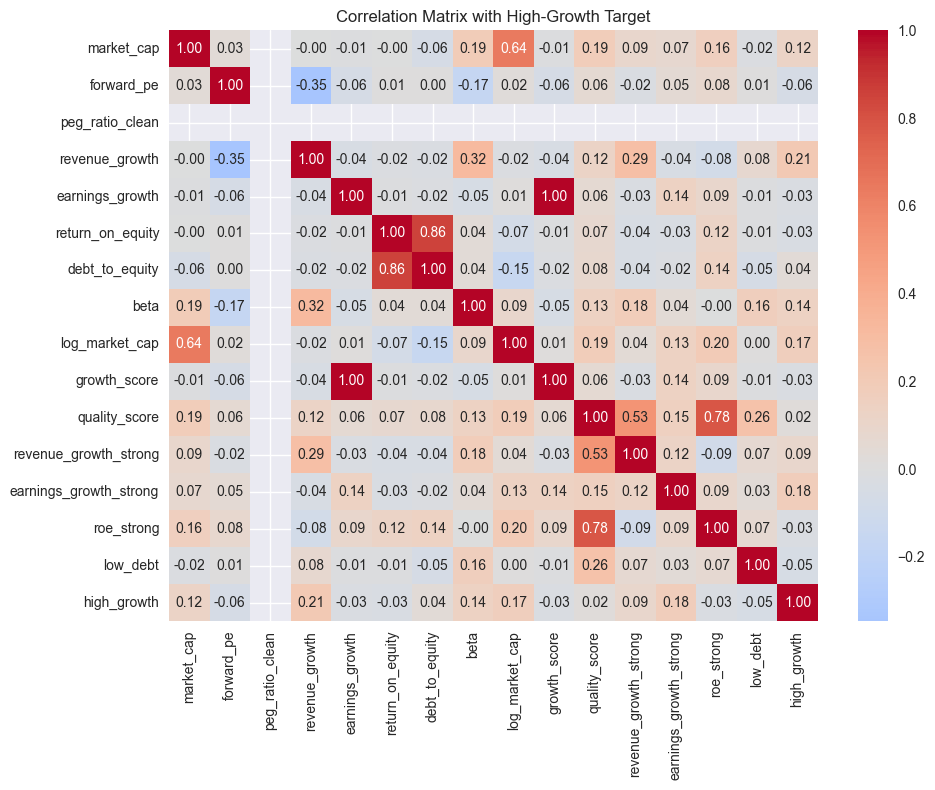

In [5]:
# CELL 5: Feature Correlation with High Growth

numeric_features = ['market_cap', 'forward_pe', 'peg_ratio_clean', 'revenue_growth', 
                    'earnings_growth', 'return_on_equity', 'debt_to_equity', 'beta',
                    'log_market_cap', 'growth_score', 'quality_score', 
                    'revenue_growth_strong', 'earnings_growth_strong', 'roe_strong', 'low_debt']

corr_with_target = df[numeric_features + ['high_growth']].corr()['high_growth'].sort_values(ascending=False)

print("📈 Top Features Correlated with High-Growth (3x+):")
print(corr_with_target.head(12))

# Visualization
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_features + ['high_growth']].corr(), cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title('Correlation Matrix with High-Growth Target')
plt.tight_layout()
plt.savefig("visualizations/top_features_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

In [6]:
# CELL 6: Save Final Engineered Dataset
# CELL 6: Save Final Engineered Dataset (Fixed with folder creation)

import os

# Ensure the folder exists before saving
os.makedirs("data/processed", exist_ok=True)

print("Saving final engineered dataset...\n")

# Select the columns for modeling
final_columns = ['ticker', 'company_name', 'sector', 'industry', 'market_cap', 
                 'forward_pe', 'peg_ratio_clean', 'revenue_growth', 
                 'earnings_growth', 'return_on_equity', 'debt_to_equity', 
                 'beta', 'log_market_cap', 'growth_score', 'quality_score',
                 'revenue_growth_strong', 'earnings_growth_strong', 
                 'roe_strong', 'low_debt', 'high_growth', 'return_5y']

final_df = df[final_columns].copy()

# Save the files
final_df.to_csv("data/processed/final_engineered_dataset.csv", index=False)
final_df.to_pickle("data/processed/final_engineered_dataset.pkl")

print("✅ Final engineered dataset saved successfully!")
print(f"Shape: {final_df.shape}")
print(f"Number of features: {len(final_columns)-3}")   # excluding ticker, company_name, target
print("\nFiles saved:")
print("   • data/processed/final_engineered_dataset.csv")
print("   • data/processed/final_engineered_dataset.pkl")
print("\nYou are now ready for the Machine Learning stage!")

Saving final engineered dataset...

✅ Final engineered dataset saved successfully!
Shape: (175, 21)
Number of features: 18

Files saved:
   • data/processed/final_engineered_dataset.csv
   • data/processed/final_engineered_dataset.pkl

You are now ready for the Machine Learning stage!
